In [1]:
import numpy as np
import polars as pl
import pandas as pd
import tensorflow as tf
import os
from libmemd import memd
from sklearn.preprocessing import StandardScaler
from working_data import clean_cols, alt_label_df as label_df, normalize_by_window, split_df
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import combined_loss


2025-06-05 02:18:43.400753: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-05 02:18:43.508610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-05 02:18:44.343079: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


ModuleNotFoundError: No module named 'libmemd'

In [ ]:
# Mixed precision
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

In [ ]:
NORMALIZING_WINDOW_SIZE = 6*24
LABELING_WINDOW_SIZE = 18
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 64
NUM_TOKENS = 64
OTHER_TOKENS = 64
LOOKBACK_WINDOW = NUM_TOKENS + 1
EMD_WINDOW_SIZE = max(OTHER_TOKENS, NUM_TOKENS) + 8
D_MODEL = 512
FF_DIM = D_MODEL*8
NUM_HEADS = D_MODEL//8

In [ ]:
source_csv = "olderdata/GBPUSD/five_minutes.csv"
source_2_csv = "olderdata/GBPUSD/hours.csv"
working_path = "working"

In [ ]:
df = pd.read_csv(source_csv)
df = clean_cols(df)
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(
    df=df, 
    dump_path=working_path,
    lookback=LOOKBACK_WINDOW,
    cols=[
        'time',
        'open',
        'high',
        'low',
        'close',
        'open_normalized',
        'high_normalized',
        'low_normalized',
        'close_normalized',
        'target'
    ])

df_alt = pd.read_csv(source_2_csv)
df_alt = clean_cols(df_alt)
df_alt = normalize_by_window(
    df_alt, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
    ])

df_alt.to_csv(os.path.join(working_path, 'larger_frame.csv'), index=False)

labeling
target
0    286076
1     14750
Name: count, dtype: int64


In [ ]:
def decompose_signal_with_memd(signal, num_imfs=4, noise_strength=0.2, ensemble_size=100):
    """
    Decompose a multivariate signal using MEMD
    
    Args:
        signal: Array of shape (n_features, n_samples)
        num_imfs: Number of IMFs to extract
        noise_strength: Strength of noise to add in MEMD
        ensemble_size: Size of ensemble for MEMD
    
    Returns:
        List of IMFs arrays, one for each feature
    """
    # Standardize each feature
    scaler = StandardScaler()
    signal_scaled = np.array([scaler.fit_transform(s.reshape(-1, 1)).flatten() for s in signal])
    
    # Apply MEMD
    imfs_list = memd(signal_scaled, num_imfs=num_imfs-1, 
                     noise_strength=noise_strength, 
                     ensemble_size=ensemble_size,
                     use_ceemdan=False)
    
    return imfs_list

In [ ]:
def prepare_data(file_path, file_path_2, num_tokens, other_tokens, num_imfs=4, 
                 window_size=1440, batch_size=32, smote=False, shuffle=False, 
                 norm_cols=['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized'],
                 raw_cols=['open', 'high', 'low', 'close']):
    """
    Prepare data for multi-resolution model with MEMD decomposition
    """
    emd_range = window_size
    
    # Load CSV lazily with Polars
    collect_cols = list(set(raw_cols + norm_cols)) + ['time', 'target']
    other_cols = list(set(raw_cols + norm_cols)) + ['time']
    df_lazy = pl.scan_csv(file_path).select(collect_cols)
    df_other = pl.scan_csv(file_path_2).select(other_cols)
    
    # Collect the dataframes
    df_collected = df_lazy.collect()
    df_other_collected = df_other.collect()
    
    # Safety mechanism: get the other_tokens-th time value from df_other_collected
    if df_other_collected.shape[0] >= other_tokens + 1:
        min_time_threshold = df_other_collected[other_tokens, 'time']
        df_collected = df_collected.filter(pl.col('time') >= min_time_threshold)
    
    total_rows = df_collected.shape[0]
    
    # For SMOTE handling
    indices_target_0 = []
    indices_target_1 = []
    
    if smote:
        df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
        indices_target_1 = df_collected.filter(
            (pl.col("target") == 1) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        df_collected = df_collected.drop('index')
    
    # Extract time arrays once for binary search
    other_time_array = df_other_collected['time'].to_numpy()
    
    while True:  # Loop to reshuffle and restart at each epoch
        # Create array of indices for shuffling
        indices = list(range(emd_range, total_rows))
        if smote:
            indices_target_1_complete = []
            while len(indices_target_1_complete) < len(indices_target_0):
                indices_target_1_complete += indices_target_1

            indices_target_1_complete = indices_target_1_complete[:len(indices_target_0)]
            indices = indices_target_0 + indices_target_1_complete

        # Shuffle indices if required
        if shuffle:
            np.random.shuffle(indices)

        # Create lists for inputs (raw IMFs and normalized)
        inputs_5min_raw_imfs = [[] for _ in range(num_imfs)]
        inputs_5min_norm = []
        inputs_hourly_raw_imfs = [[] for _ in range(num_imfs)]
        inputs_hourly_norm = []
        targets = []

        for idx in indices:
            # Get the 5-minute data
            signal_5min_raw = np.array(df_collected[raw_cols][idx - emd_range + 1:idx + 1])
            signal_5min_norm = np.array(df_collected[norm_cols][idx - emd_range + 1:idx + 1])
            signal_time_index = df_collected[idx, 'time']

            # Find the corresponding position in hourly data
            pos = np.searchsorted(other_time_array, signal_time_index, side='right') - 1
            
            # Ensure we have enough hourly data
            if pos >= other_tokens:
                # Get the hourly data
                signal_hourly_raw = np.array(df_other_collected[pos-other_tokens:pos, raw_cols])
                signal_hourly_norm = np.array(df_other_collected[pos-other_tokens:pos, norm_cols])
                
                # Decompose 5-minute raw data with MEMD
                # Transpose to get shape (n_features, n_samples)
                signal_5min_raw_T = signal_5min_raw.T
                imfs_5min = decompose_signal_with_memd(signal_5min_raw_T, num_imfs=num_imfs)
                
                # Decompose hourly raw data with MEMD
                signal_hourly_raw_T = signal_hourly_raw.T
                imfs_hourly = decompose_signal_with_memd(signal_hourly_raw_T, num_imfs=num_imfs)
                
                # Get the target
                target_value = df_collected[idx, 'target']
                
                # Extract the window we need for each IMF
                for imf_idx in range(num_imfs):
                    # For 5-minute data, extract the last num_tokens rows for each IMF
                    # Each IMF is of shape (n_samples, n_features)
                    imf_5min_data = np.array([imfs_5min[feature_idx][imf_idx][-num_tokens:] 
                                            for feature_idx in range(len(raw_cols))]).T
                    inputs_5min_raw_imfs[imf_idx].append(imf_5min_data)
                    
                    # For hourly data
                    imf_hourly_data = np.array([imfs_hourly[feature_idx][imf_idx][-other_tokens:] 
                                              for feature_idx in range(len(raw_cols))]).T
                    inputs_hourly_raw_imfs[imf_idx].append(imf_hourly_data)
                
                # Add normalized data
                inputs_5min_norm.append(signal_5min_norm[-num_tokens:])
                inputs_hourly_norm.append(signal_hourly_norm)
                
                # Add target
                targets.append(target_value)
                
                # Yield once we have enough for a batch
                if len(targets) == batch_size:
                    # Convert all inputs to tensors
                    tensor_inputs = []
                    
                    # Add 5-minute IMFs
                    for imf_idx in range(num_imfs):
                        tensor_inputs.append(tf.convert_to_tensor(
                            np.array(inputs_5min_raw_imfs[imf_idx]), dtype=tf.float32))
                    
                    # Add 5-minute normalized
                    tensor_inputs.append(tf.convert_to_tensor(
                        np.array(inputs_5min_norm), dtype=tf.float32))
                    
                    # Add hourly IMFs
                    for imf_idx in range(num_imfs):
                        tensor_inputs.append(tf.convert_to_tensor(
                            np.array(inputs_hourly_raw_imfs[imf_idx]), dtype=tf.float32))
                    
                    # Add hourly normalized
                    tensor_inputs.append(tf.convert_to_tensor(
                        np.array(inputs_hourly_norm), dtype=tf.float32))
                    
                    # Add target
                    target_tensor = tf.convert_to_tensor(np.array(targets), dtype=tf.int32)
                    
                    yield tuple(tensor_inputs), target_tensor
                    
                    # Reset all lists
                    inputs_5min_raw_imfs = [[] for _ in range(num_imfs)]
                    inputs_5min_norm = []
                    inputs_hourly_raw_imfs = [[] for _ in range(num_imfs)]
                    inputs_hourly_norm = []
                    targets = []

        # Handle remaining samples
        if targets:
            tensor_inputs = []
            
            # Add 5-minute IMFs
            for imf_idx in range(num_imfs):
                tensor_inputs.append(tf.convert_to_tensor(
                    np.array(inputs_5min_raw_imfs[imf_idx]), dtype=tf.float32))
            
            # Add 5-minute normalized
            tensor_inputs.append(tf.convert_to_tensor(
                np.array(inputs_5min_norm), dtype=tf.float32))
            
            # Add hourly IMFs
            for imf_idx in range(num_imfs):
                tensor_inputs.append(tf.convert_to_tensor(
                    np.array(inputs_hourly_raw_imfs[imf_idx]), dtype=tf.float32))
            
            # Add hourly normalized
            tensor_inputs.append(tf.convert_to_tensor(
                np.array(inputs_hourly_norm), dtype=tf.float32))
            
            # Add target
            target_tensor = tf.convert_to_tensor(np.array(targets), dtype=tf.int32)
            
            yield tuple(tensor_inputs), target_tensor
        
        break

In [ ]:
def create_dataset_generator(file_path, file_path_2, batch_size, num_tokens, other_tokens, 
                             num_imfs=4, window_size=1440, shuffle=False, repeat=False, smote=False, 
                             norm_cols=['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized'],
                             raw_cols=['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized']):
    """
    Create a TensorFlow dataset with MEMD decomposition for both 5-minute and hourly data
    """
    # Create output signature for the dataset
    output_signatures = []
    
    # 5-minute IMFs
    for _ in range(num_imfs):
        output_signatures.append(tf.TensorSpec(shape=(None, num_tokens, len(raw_cols)), dtype=tf.float32))
    
    # 5-minute normalized
    output_signatures.append(tf.TensorSpec(shape=(None, num_tokens, len(norm_cols)), dtype=tf.float32))
    
    # Hourly IMFs
    for _ in range(num_imfs):
        output_signatures.append(tf.TensorSpec(shape=(None, other_tokens, len(raw_cols)), dtype=tf.float32))
    
    # Hourly normalized
    output_signatures.append(tf.TensorSpec(shape=(None, other_tokens, len(norm_cols)), dtype=tf.float32))
    
    # Create the dataset
    dataset = tf.data.Dataset.from_generator(
        lambda: prepare_data(file_path, file_path_2, window_size=window_size, batch_size=batch_size, 
                           num_tokens=num_tokens, other_tokens=other_tokens, num_imfs=num_imfs,
                           shuffle=shuffle, smote=smote, norm_cols=norm_cols, raw_cols=raw_cols),
        output_signature=(
            tuple(output_signatures),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )

    if repeat:
        dataset = dataset.repeat()
    return dataset



def get_total_rows(file_path, file_path_2, num_tokens, other_tokens, window_size=1440, smote=False):
    """Calculate total number of rows for steps per epoch calculation"""
    # Same implementation as before
    df_lazy = pl.scan_csv(file_path)
    df_collected = df_lazy.collect()
    
    df_other = pl.scan_csv(file_path_2)
    df_other_collected = df_other.collect()
    
    if df_other_collected.shape[0] >= other_tokens + 1:
        min_time_threshold = df_other_collected[other_tokens, 'time']
        df_collected = df_collected.filter(pl.col('time') >= min_time_threshold)
    
    total_rows = df_collected.shape[0]
    
    if not smote:
        return total_rows
    
    df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
    indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= window_size)
    )
    return len(indices_target_0) * 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, concatenate, LayerNormalization, Dropout, Lambda, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Add, Embedding

input_length = NUM_TOKENS 

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]
    
class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(LearnablePositionalEncoding, self).__init__()
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=d_model)
        
    def call(self, inputs):
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        positions = self.pos_emb(positions)
        # Add the position embeddings to the input embeddings
        # Remove the erroneous newaxis dimension
        return inputs + positions[tf.newaxis, :, :]


    
class StochasticGatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, 
                 attention_dropout=0.1, stochastic_depth_rate=0.1):
        super(StochasticGatedTransformerBlock, self).__init__()
        
        # Standard multi-head attention from original implementation
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=embed_dim//num_heads,  # key_dim is per head
            dropout=attention_dropout
        )
        
        self.stochastic_depth_rate = stochastic_depth_rate
        
        # Gating mechanism for attention with stochastic noise
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def stochastic_depth(self, x, training):
        """Applies stochastic depth to the input tensor."""
        # Store original dtype for consistent handling
        dtype = x.dtype
        
        def drop_path():
            batch_size = tf.shape(x)[0]
            # Create binary tensor with probability of keeping activations
            keep_prob = tf.cast(1.0 - self.stochastic_depth_rate, dtype=dtype)
            
            random_tensor = keep_prob
            random_tensor += tf.cast(tf.random.uniform([batch_size, 1, 1]), dtype=dtype)
            binary_tensor = tf.floor(random_tensor)
            
            # Scale the activations
            return x * binary_tensor / keep_prob
            
        return tf.cond(
            tf.logical_and(training, tf.constant(self.stochastic_depth_rate > 0)),
            lambda: drop_path(),
            lambda: x
        )

    def call(self, inputs, training=True):
        # Convert string 'True' to boolean True if needed
        if isinstance(training, str):
            training = training == 'True'
            
        # Store original dtype for consistent handling
        input_dtype = inputs.dtype
        
        # Handle stochastic depth with tf.cond
        def skip_block():
            return inputs
            
        def process_block():
            # Apply noise during training
            def apply_training_noise():
                noise_scale = tf.cast(0.01, dtype=input_dtype)
                input_noise = tf.random.normal(tf.shape(inputs), stddev=noise_scale, dtype=input_dtype)
                return inputs + input_noise
                
            inputs_with_noise = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_training_noise(),
                lambda: inputs
            )
                
            # Apply multi-head attention
            attn_output = self.att(inputs_with_noise, inputs_with_noise)
            
            # Apply gating to attention output
            gate_val = self.gate_att(inputs)
            
            # Add multiplicative noise to gates during training
            def add_gate_noise():
                gate_noise = tf.random.normal(
                    tf.shape(gate_val), 
                    mean=tf.cast(1.0, dtype=input_dtype), 
                    stddev=tf.cast(0.1, dtype=input_dtype),
                    dtype=input_dtype
                )
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_gate_noise(),
                lambda: gate_val
            )
                
            attn_output = gate_val * attn_output
            
            # Apply dropout and add residual connection
            attn_output = self.dropout1(attn_output, training=training)
            out1 = self.layernorm1(inputs + attn_output)
            
            # Feed-forward network with gating
            ffn_output = self.ff1(out1)
            
            # Apply stochastic feature dropout during training
            def apply_feature_dropout():
                # Randomly zero out some features
                feature_mask = tf.cast(
                    tf.random.uniform(tf.shape(ffn_output), dtype=input_dtype) > tf.cast(0.1, dtype=input_dtype), 
                    dtype=input_dtype
                )
                # Scale to maintain expected value
                return ffn_output * feature_mask * tf.cast(1.1, dtype=input_dtype)
                
            ffn_output = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_feature_dropout(),
                lambda: ffn_output
            )
                
            ffn_output = self.ff2(ffn_output)
            gate_val = self.gate_ffn(out1)
            
            # Add noise to FFN gates during training
            def add_ffn_gate_noise():
                gate_noise = tf.random.normal(
                    tf.shape(gate_val), 
                    mean=tf.cast(1.0, dtype=input_dtype), 
                    stddev=tf.cast(0.1, dtype=input_dtype),
                    dtype=input_dtype
                )
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_ffn_gate_noise(),
                lambda: gate_val
            )
                
            ffn_output = gate_val * ffn_output
            ffn_output = self.dropout2(ffn_output, training=training)
            
            # Apply stochastic depth to the residual connection
            ffn_output = self.stochastic_depth(ffn_output, training)
            
            return self.layernorm2(out1 + ffn_output)
        
        # Use tf.cond for the main block execution decision
        random_value = tf.random.uniform([], dtype=input_dtype)
        skip_condition = tf.logical_and(
            tf.cast(training, tf.bool),
            tf.less(random_value, tf.cast(self.stochastic_depth_rate, dtype=input_dtype))
        )
        
        return tf.cond(skip_condition, skip_block, process_block)
        
    def compute_output_shape(self, input_shape):
        return input_shape

In [ ]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [ ]:
train_path = 'working/train.csv'
train_path_2 = 'working/larger_frame.csv'
val_path = 'working/val.csv'
val_path_2 = train_path_2
test_path = 'working/test.csv'
test_path_2 = train_path_2

num_imfs = 5
norm_cols = ['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized']
raw_cols = ['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized']

In [ ]:
train_dataset = create_dataset_generator(
    train_path, train_path_2, batch_size=BATCH_SIZE, window_size=EMD_WINDOW_SIZE,
    num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, 
    num_imfs=num_imfs, repeat=True, shuffle=True, smote=True, 
    norm_cols=norm_cols, raw_cols=raw_cols
)

val_dataset = create_dataset_generator(
    val_path, val_path_2, batch_size=BATCH_SIZE, window_size=EMD_WINDOW_SIZE,
    num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, 
    num_imfs=num_imfs, repeat=True, 
    norm_cols=norm_cols, raw_cols=raw_cols
)

test_dataset = create_dataset_generator(
    test_path, test_path_2, batch_size=BATCH_SIZE, window_size=EMD_WINDOW_SIZE,
    num_tokens=NUM_TOKENS, other_tokens=OTHER_TOKENS, 
    num_imfs=num_imfs,
    norm_cols=norm_cols, raw_cols=raw_cols
)

train_steps = get_total_rows(train_path, train_path_2, num_tokens=LOOKBACK_WINDOW, 
                             other_tokens=OTHER_TOKENS, smote=True)//BATCH_SIZE
val_steps = get_total_rows(val_path, val_path_2, num_tokens=LOOKBACK_WINDOW, 
                           other_tokens=OTHER_TOKENS)//BATCH_SIZE
test_steps = get_total_rows(test_path, test_path_2, num_tokens=LOOKBACK_WINDOW, 
                            other_tokens=OTHER_TOKENS)//BATCH_SIZE

In [ ]:
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-3, warmup_steps=10000, decay_steps=100000):
        super(WarmupCosineDecay, self).__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        
    def __call__(self, step):
        # Linear warmup
        warmup_lr = self.initial_lr * (tf.cast(step, tf.float32) / 
                                      tf.cast(self.warmup_steps, tf.float32))
        
        # Cosine decay
        cosine_decay = 0.5 * (1 + tf.cos(
            3.14159 * (tf.cast(step, tf.float32) - self.warmup_steps) / 
            tf.cast(self.decay_steps - self.warmup_steps, tf.float32)))
        decay_lr = self.initial_lr * cosine_decay
        
        # Use warmup_lr for the first warmup_steps, then decay_lr
        lr = tf.where(step < self.warmup_steps, warmup_lr, decay_lr)
        return lr
    
    def get_config(self):
        """Required for serialization when saving the model."""
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "decay_steps": self.decay_steps
        }

In [ ]:
class LearnableTypeEncoding(tf.keras.layers.Layer):
    """
    A learnable embedding layer that adds timeframe and signal type information
    to input tensors without reducing their feature dimensions.
    
    Args:
        timeframe_type: 0 for 5-minute data, 1 for hourly data
        signal_number: 0 for normalized data, 1+ for IMF number (e.g., 1, 2, 3, 4)
        embedding_dim: Size of the embedding to add
    """
    def __init__(self, timeframe_type, signal_number, embedding_dim=2, **kwargs):
        super(LearnableTypeEncoding, self).__init__(**kwargs)
        self.timeframe_type = timeframe_type  # 0 = 5min, 1 = hourly
        self.signal_number = signal_number    # 0 = normalized, 1+ = IMF number
        self.embedding_dim = embedding_dim
        
    def build(self, input_shape):
        # Create learnable weights for timeframe (5min vs hourly)
        self.timeframe_embeddings = self.add_weight(
            shape=(2, self.embedding_dim),  # 2 types (5min, hourly)
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02),
            trainable=True,
            name="timeframe_embeddings"
        )
        
        # Create learnable weights for signal type (normalized vs IMF number)
        max_signals = 10  # Support up to 9 IMFs + normalized (0)
        self.signal_embeddings = self.add_weight(
            shape=(max_signals, self.embedding_dim),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02),
            trainable=True,
            name="signal_embeddings"
        )
        
        super(LearnableTypeEncoding, self).build(input_shape)
    
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        
        # Get the embeddings for the specified timeframe and signal
        timeframe_embed = self.timeframe_embeddings[self.timeframe_type]  # Shape: (embedding_dim,)
        signal_embed = self.signal_embeddings[self.signal_number]         # Shape: (embedding_dim,)
        
        # Combine the embeddings
        combined_embed = tf.concat([timeframe_embed, signal_embed], axis=0)  # Shape: (2*embedding_dim,)
        
        # Expand to match batch and sequence dimensions
        # Shape: (batch_size, seq_len, 2*embedding_dim)
        expanded_embed = tf.tile(
            tf.reshape(combined_embed, [1, 1, 2*self.embedding_dim]),
            [batch_size, seq_len, 1]
        )
        
        # Concatenate with the input along the feature dimension
        return tf.concat([inputs, expanded_embed], axis=-1)
    
    def get_config(self):
        config = super(LearnableTypeEncoding, self).get_config()
        config.update({
            'timeframe_type': self.timeframe_type,
            'signal_number': self.signal_number,
            'embedding_dim': self.embedding_dim
        })
        return config

In [ ]:
def create_model(num_imfs=num_imfs, training=True):
    """Create a model using the decomposed IMFs and normalized data"""
    norm_cols = ['open', 'high', 'low', 'close']
    raw_cols = ['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized']
    
    # Create input layers
    inputs = []
    
    # 5-minute IMF inputs
    for i in range(num_imfs):
        inputs.append(Input(shape=(NUM_TOKENS, len(raw_cols)), name=f'minute_imf_{i+1}'))
    
    # 5-minute normalized input
    inputs.append(Input(shape=(NUM_TOKENS, len(norm_cols)), name='minute_norm'))
    
    # Hourly IMF inputs
    for i in range(num_imfs):
        inputs.append(Input(shape=(OTHER_TOKENS, len(raw_cols)), name=f'hourly_imf_{i+1}'))
    
    # Hourly normalized input
    inputs.append(Input(shape=(OTHER_TOKENS, len(norm_cols)), name='hourly_norm'))
    
    # Process each input branch
    final_branches = []
    
    # Process 5-minute IMFs
    for i in range(num_imfs):
        branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(inputs[i])
        branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(branch)
        
        # Pooling
        max_pool = MaxPooling1D(pool_size=2, padding="same")(branch)
        avg_pool = AveragePooling1D(pool_size=2, padding="same")(branch)
        branch = concatenate([max_pool, avg_pool], axis=-1)
        branch = Dropout(0.2)(branch)
        
        # Position encoding - Create embeddings with correct shape
        def create_type_embed_5min(x):
            return tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.1
        
        def create_signal_embed_5min(x, signal_idx=i+1):
            return tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.1 * signal_idx
        
        type_embed_5min = Lambda(create_type_embed_5min)(branch)
        signal_no_embed_5min = Lambda(lambda x: create_signal_embed_5min(x, i+1))(branch)
        branch = concatenate([branch, type_embed_5min, signal_no_embed_5min], axis=-1)
        
        max_seq_len_after_pooling = NUM_TOKENS // 2
        branch = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL)(branch)
        
        final_branches.append(branch)
    
    # Process 5-minute normalized
    norm_branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(inputs[num_imfs])
    norm_branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(norm_branch)
    
    # Pooling
    max_pool = MaxPooling1D(pool_size=2, padding="same")(norm_branch)
    avg_pool = AveragePooling1D(pool_size=2, padding="same")(norm_branch)
    norm_branch = concatenate([max_pool, avg_pool], axis=-1)
    norm_branch = Dropout(0.2)(norm_branch)

    type_embed_5min_norm = Lambda(lambda x: tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.1)(norm_branch)
    signal_no_embed_5min_norm = Lambda(lambda x: tf.zeros((tf.shape(x)[0], tf.shape(x)[1], 1)))(norm_branch)
    norm_branch = concatenate([norm_branch, type_embed_5min_norm, signal_no_embed_5min_norm], axis=-1)
    
    # Position encoding
    max_seq_len_after_pooling = NUM_TOKENS // 2
    norm_branch = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL)(norm_branch)
    
    final_branches.append(norm_branch)
    
    # Process hourly IMFs
    for i in range(num_imfs):
        branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(inputs[num_imfs+1+i])
        branch = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(branch)
        
        # Pooling
        max_pool = MaxPooling1D(pool_size=2, padding="same")(branch)
        avg_pool = AveragePooling1D(pool_size=2, padding="same")(branch)
        branch = concatenate([max_pool, avg_pool], axis=-1)
        branch = Dropout(0.2)(branch)
        
        # Position encoding - Create embeddings with correct shape
        def create_type_embed_hour(x):
            return tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.3
        
        def create_signal_embed_hour(x, signal_idx=i+1):
            return tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.1 * signal_idx
        
        type_embed_hour = Lambda(create_type_embed_hour)(branch)
        signal_no_embed_hour = Lambda(lambda x: create_signal_embed_hour(x, i+1))(branch)
        branch = concatenate([branch, type_embed_hour, signal_no_embed_hour], axis=-1)
        
        max_seq_len_after_pooling = OTHER_TOKENS // 2
        branch = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL)(branch)
        
        final_branches.append(branch)
    
    # Process hourly normalized
    norm_branch_hourly = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(inputs[2*num_imfs+1])
    norm_branch_hourly = Conv1D(filters=(D_MODEL//2)-1, kernel_size=3, activation='relu', padding="same")(norm_branch_hourly)
    
    # Pooling
    max_pool = MaxPooling1D(pool_size=2, padding="same")(norm_branch_hourly)
    avg_pool = AveragePooling1D(pool_size=2, padding="same")(norm_branch_hourly)
    norm_branch_hourly = concatenate([max_pool, avg_pool], axis=-1)
    norm_branch_hourly = Dropout(0.2)(norm_branch_hourly)
    
    # Position encoding
    type_embed_hour_norm = Lambda(lambda x: tf.ones((tf.shape(x)[0], tf.shape(x)[1], 1)) * 0.3)(norm_branch_hourly)
    signal_no_embed_hour_norm = Lambda(lambda x: tf.zeros((tf.shape(x)[0], tf.shape(x)[1], 1)))(norm_branch_hourly)
    norm_branch_hourly = concatenate([norm_branch_hourly, type_embed_hour_norm, signal_no_embed_hour_norm], axis=-1)
    
    max_seq_len_after_pooling = OTHER_TOKENS // 2
    norm_branch_hourly = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL)(norm_branch_hourly)
    final_branches.append(norm_branch_hourly)
    
    x = concatenate(final_branches, axis=1)
    
    # Apply transformer blocks
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.1
    )(x, training=training)
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.2
    )(x, training=training)
    
    # Global pooling features
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    
    # Combine features
    combined_features = concatenate([avg_pool, max_pool])
    combined_features = Dropout(0.1)(combined_features)
    
    # Final classifier
    outputs = Dense(1, activation='sigmoid')(combined_features)
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs)
    
    return model


model = create_model(training=True)

lr_schedule = WarmupCosineDecay(initial_lr=1e-3, warmup_steps=3000, decay_steps=30000)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy', auc, prec])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ minute_imf_1        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_2        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_3        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_4        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_5        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_norm         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_1        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_2        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_3        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_4        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_5        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_norm         │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 128, 4)    │          0 │ minute_imf_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 128, 4)    │          0 │ minute_imf_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_2 (Cast)       │ (None, 128, 4)    │          0 │ minute_imf_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_3 (Cast)       │ (None, 128, 4)    │          0 │ minute_imf_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_4 (Cast)       │ (None, 128, 4)    │          0 │ minute_imf_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_5 (Cast)       │ (None, 128, 4)    │          0 │ minute_norm[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_6 (Cast)       │ (None, 64, 4)     │          0 │ hourly_imf_1[0][

 Total params: 3,105,625 (11.85 MB)

 Trainable params: 3,105,625 (11.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=10, # Stops if there's no improvement for 3 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_multiresolution_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50


I0000 00:00:1748380432.985994  748246 service.cc:145] XLA service 0x7efbe80123d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748380432.986077  748246 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
W0000 00:00:1748380433.366874  748246 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/stochastic_gated_transformer_block_1/random_uniform/RandomUniform
2025-05-27 23:13:53.372261: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-27 23:13:55.725439: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1748380467.846393  748246 asm_compiler.cc:369] ptxas warning : Registers are

6147/6147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7017 - auc: 0.7671 - loss: 0.8784 - precision_1: 0.6895
Epoch 1: val_loss improved from inf to 0.99301, saving model to best_multiresolution_model.keras
6147/6147 ━━━━━━━━━━━━━━━━━━━━ 10281s 2s/step - accuracy: 0.7017 - auc: 0.7671 - loss: 0.8784 - precision_1: 0.6895 - val_accuracy: 0.7943 - val_auc: 0.8729 - val_loss: 0.9930 - val_precision_1: 0.1754
Epoch 2/50
  40/6147 ━━━━━━━━━━━━━━━━━━━━ 2:31:07 1s/step - accuracy: 0.8425 - auc: 0.8982 - loss: 0.6146 - precision_1: 0.7980

I0000 00:00:1748390799.758341  748256 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_6', 24 bytes spill stores, 24 bytes spill loads



6147/6147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8434 - auc: 0.9056 - loss: 0.6048 - precision_1: 0.8031
Epoch 2: val_loss improved from 0.99301 to 0.93830, saving model to best_multiresolution_model.keras
6147/6147 ━━━━━━━━━━━━━━━━━━━━ 9986s 2s/step - accuracy: 0.8434 - auc: 0.9056 - loss: 0.6048 - precision_1: 0.8031 - val_accuracy: 0.8424 - val_auc: 0.8572 - val_loss: 0.9383 - val_precision_1: 0.1897
Epoch 3/50
6147/6147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8901 - auc: 0.9447 - loss: 0.4861 - precision_1: 0.8523
Epoch 3: val_loss improved from 0.93830 to 0.90626, saving model to best_multiresolution_model.keras
6147/6147 ━━━━━━━━━━━━━━━━━━━━ 9172s 1s/step - accuracy: 0.8902 - auc: 0.9447 - loss: 0.4861 - precision_1: 0.8523 - val_accuracy: 0.8594 - val_auc: 0.8567 - val_loss: 0.9063 - val_precision_1: 0.2029
Epoch 4/50
6147/6147 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9218 - auc: 0.9673 - loss: 0.3998 - precision_1: 0.8889
Epoch 4: val_loss did not improve from

Debug Information:
NUM_TOKENS: 128
OTHER_TOKENS: 64
D_MODEL: 256
num_imfs: 5

Expected shapes after pooling:
5-minute branches after pooling: 64
Hourly branches after pooling: 32

Testing model creation...
Model created successfully!


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ minute_imf_1        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_2        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_3        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_4        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_imf_5        │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_norm         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_1        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_2        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_3        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_4        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_imf_5        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_norm         │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_48 (Cast)      │ (None, 128, 4)    │          0 │ minute_imf_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_49 (Cast)      │ (None, 128, 4)    │          0 │ minute_imf_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_50 (Cast)      │ (None, 128, 4)    │          0 │ minute_imf_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_51 (Cast)      │ (None, 128, 4)    │          0 │ minute_imf_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_52 (Cast)      │ (None, 128, 4)    │          0 │ minute_imf_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_53 (Cast)      │ (None, 128, 4)    │          0 │ minute_norm[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_54 (Cast)      │ (None, 64, 4)     │          0 │ hourly_imf_1[0][

 Total params: 3,105,625 (11.85 MB)

 Trainable params: 3,105,625 (11.85 MB)

 Non-trainable params: 0 (0.00 B)


Checking dataset shapes...
Number of inputs: 12
Input 0 shape: (128, 128, 4)
Input 1 shape: (128, 128, 4)
Input 2 shape: (128, 128, 4)
Input 3 shape: (128, 128, 4)
Input 4 shape: (128, 128, 4)
Input 5 shape: (128, 128, 4)
Input 6 shape: (128, 64, 4)
Input 7 shape: (128, 64, 4)
Input 8 shape: (128, 64, 4)
Input 9 shape: (128, 64, 4)
Input 10 shape: (128, 64, 4)
Input 11 shape: (128, 64, 4)
Target shape: (128,)


In [ ]:
# Inspect the dataset structure
for data in train_dataset.take(1):
    for i, item in enumerate(data):
        print(data[0][0][0][-1][-1])
        print('\n\n\n\n')
        print(data[0][1][0][-1][-1])
        break

tf.Tensor(-0.038086798, shape=(), dtype=float32)





tf.Tensor(0.21892633, shape=(), dtype=float32)


2025-05-26 09:44:29.606956: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
model = create_model(training=False)
model.load_weights('best_multiresolution_model.keras')

# Make predictions
predictions = model.predict(test_dataset, steps=test_steps)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

2025-05-27 10:18:58.376290: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1748333938.417049  616538 service.cc:145] XLA service 0x7f65b8019c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748333938.417206  616538 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
W0000 00:00:1748333938.585683  616538 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1_1/stochastic_gated_transformer_block_2_1/random_uniform/RandomUniform
2025-05-27 10:18:58.651072: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-27 10:

352/352 ━━━━━━━━━━━━━━━━━━━━ 845s 2s/step


Confusion Matrix:
 [[38981  3799]
 [ 1258   949]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     42780
           1       0.20      0.43      0.27      2207

    accuracy                           0.89     44987
   macro avg       0.58      0.67      0.61     44987
weighted avg       0.93      0.89      0.91     44987



2025-05-27 10:46:20.107877: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


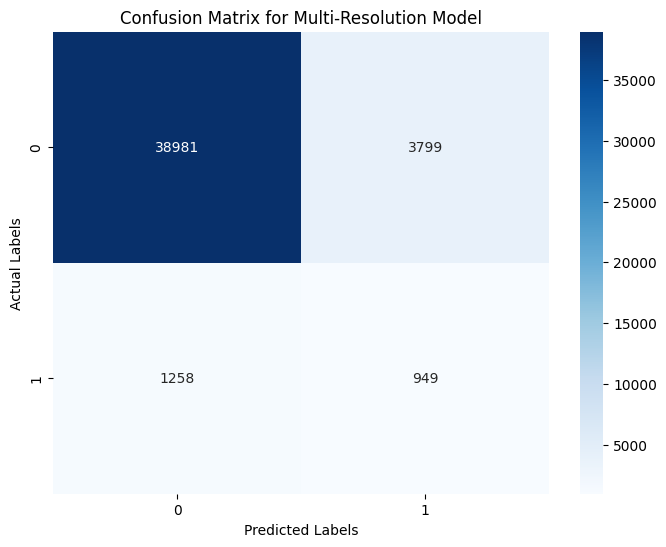

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Collect ground truth labels
y_true = []
for inputs in test_dataset:
    # The test_dataset now returns a tuple of two inputs and one target
    if len(inputs) == 3:  # If unpacked
        minute_input, hourly_input, target = inputs
    else:  # If not unpacked
        target = inputs[-1]
    y_true.extend(target.numpy())
    # Break if we've processed all the steps
    if len(y_true) >= test_steps * BATCH_SIZE:
        break

# Truncate to match the length of predictions
y_true = y_true[:len(predicted_class)]

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, predicted_class))

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Multi-Resolution Model')
plt.show()

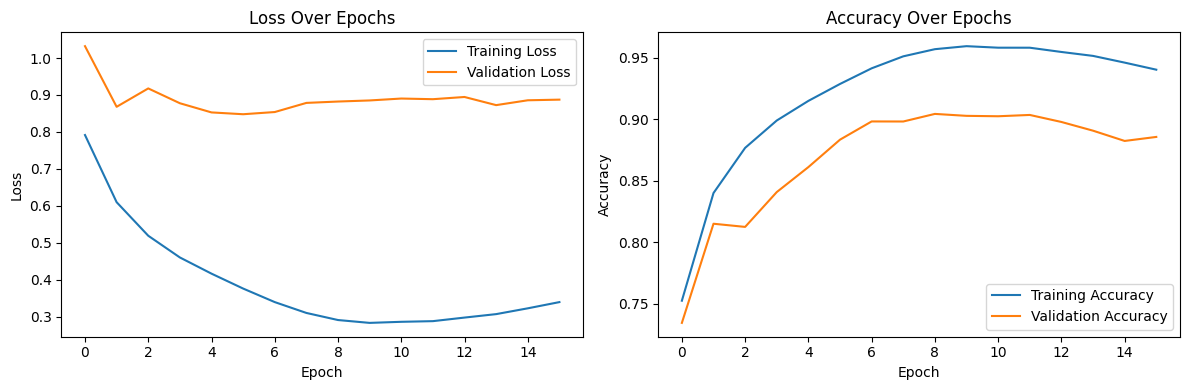

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()